In [ ]:
import pandas as pd
import numpy as np

# 1. Load all sheets from the Excel file
excel_file = 'FitPulse_2024_Operations.xlsx'
members = pd.read_excel(excel_file, sheet_name='Memberships_Fact')
costs = pd.read_excel(excel_file, sheet_name='Cost_Lookup')
targets = pd.read_excel(excel_file, sheet_name='Region_Targets')

# 2. Merge transaction data with cost lookups
df = members.merge(costs, on='PlanType', how='left')

# 3. Calculate financial metrics required for the lab
# Effective Monthly Fee after discount
df['EffectiveMonthlyFee'] = df['MonthlyFee'] * (1 - df['DiscountRate'])

# Total Revenue generated over active days
df['TotalRevenue'] = df['EffectiveMonthlyFee'] * (df['DaysActive'] / 30.0)

# Total Trainer Payroll Cost
df['TotalTrainerCost'] = df['TrainerSessionsBooked'] * df['TrainerPayrollCostPerSession']

# Total Operating Cost (Base Onboarding Cost + Trainer Cost)
df['TotalCost'] = df['BaseOnboardingCost'] + df['TotalTrainerCost']

# Net Operating Profit & Profit Margin %
df['NetProfit'] = df['TotalRevenue'] - df['TotalCost']
df['ProfitMargin'] = (df['NetProfit'] / df['TotalRevenue']) * 100

# Early Churn Flags & Financial Loss (Cancelled within 60 days)
df['IsEarlyChurn'] = (df['ContractStatus'] == 'Cancelled') & (df['DaysActive'] <= 60)
df['EarlyChurnLoss'] = np.where(df['IsEarlyChurn'], df['BaseOnboardingCost'] - df['NetProfit'], 0)

# 4. Save the cleaned dataset as a CSV
output_filename = 'FitPulse_Cleaned_Operations.csv'
df.to_csv(output_filename, index=False)

print(f"Dataset successfully cleaned and saved as '{output_filename}'!")
df.head()

Dataset successfully cleaned and saved as 'FitPulse_Cleaned_Operations.csv'!


,MemberID,JoinDate,BranchRegion,PlanType,MonthlyFee,DiscountRate,ContractStatus,DaysActive,TrainerSessionsBooked,BaseOnboardingCost,TrainerPayrollCostPerSession,EffectiveMonthlyFee,TotalRevenue,TotalTrainerCost,TotalCost,NetProfit,ProfitMargin,IsEarlyChurn,EarlyChurnLoss
0,FP-1001,2024-01-03,Urban-Central,Standard,59,0.20,Active,90,2,70,25,47.20,141.60,50,120,21.60,15.254237,False,0.0
1,FP-1002,2024-01-05,Northern,Standard,59,0.15,Active,90,0,70,25,50.15,150.45,0,70,80.45,53.472915,False,0.0
2,FP-1003,2024-01-05,Urban-Central,Premium,119,0.20,Active,90,5,110,40,95.20,285.60,200,310,-24.40,-8.543417,False,0.0
3,FP-1004,2024-01-06,Urban-Central,Corporate,89,0.10,Active,90,0,90,30,80.10,240.30,0,90,150.30,62.546816,False,0.0
4,FP-1005,2024-01-08,Coastal,Standard,59,0.30,Active,90,2,70,25,41.30,123.90,50,120,3.90,3.147700,False,0.0


##**CORRECTED CODE**

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


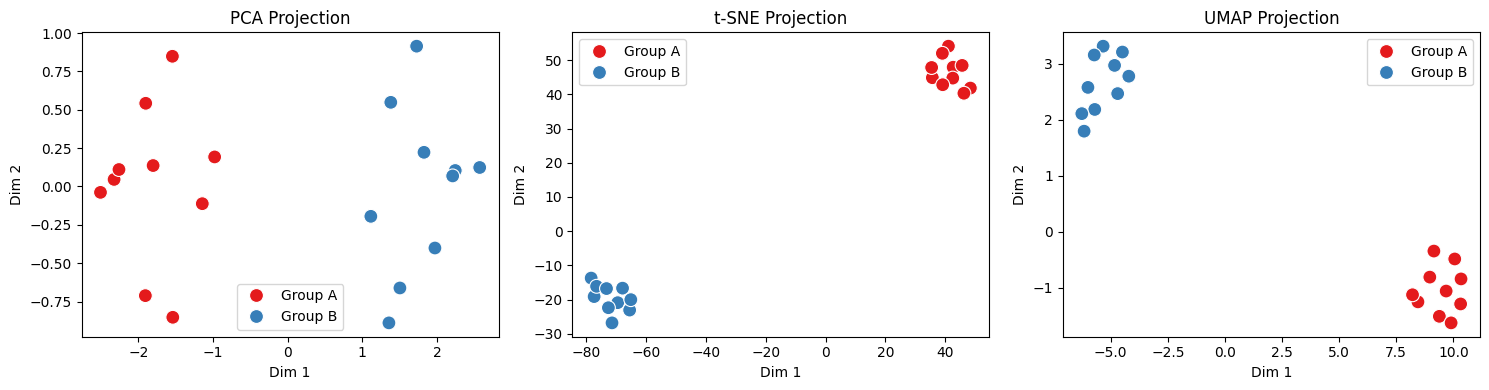

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# --- DATASET GENERATION (Do not change) ---
np.random.seed(42)
data = np.random.randn(20, 4)
data[10:, :] += 3.5  # Create 2 groups
labels = ['Group A']*10 + ['Group B']*10
df = pd.DataFrame(data, columns=['F1', 'F2', 'F3', 'F4'])

# FIX 1: Apply StandardScaler properly to the dataframe
X_scaled = StandardScaler().fit_transform(df)

# Dimensionality Reduction
pca_res = PCA(n_components=2).fit_transform(X_scaled)

# FIX 2: Set perplexity strictly less than n_samples (20 samples -> perplexity = 5)
tsne_res = TSNE(n_components=2, perplexity=5, random_state=42).fit_transform(X_scaled)

# UMAP
umap_res = umap.UMAP(n_components=2, n_neighbors=5, random_state=42).fit_transform(X_scaled)

# Plotting side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
results = [('PCA', pca_res), ('t-SNE', tsne_res), ('UMAP', umap_res)]

for ax, (title, res_data) in zip(axes, results):
    plot_df = pd.DataFrame(res_data, columns=['Dim 1', 'Dim 2'])

    # FIX 3: Pass hue=labels to color-code Group A and Group B
    sns.scatterplot(data=plot_df, x='Dim 1', y='Dim 2', hue=labels, ax=ax, s=100, palette='Set1')
    ax.set_title(f"{title} Projection")
    ax.legend(loc='best')

plt.tight_layout()
plt.show()